In [2]:
import importlib

packages = [
    "torch",
    "torchvision",
    "matplotlib",
    "seaborn",
    "sklearn",
    "pandas"
]

for pkg in packages:
    try:
        module = importlib.import_module(pkg)
        print(f"{pkg} installed | Version: {module.__version__}")
    except ImportError:
        print(f"{pkg} is NOT installed")

torch installed | Version: 2.10.0+cu128
torchvision installed | Version: 0.25.0+cu128
matplotlib installed | Version: 3.10.6
seaborn installed | Version: 0.13.2
sklearn installed | Version: 1.8.0
pandas installed | Version: 2.3.3


In [12]:
import sys
!{sys.executable} -m pip install torchsummary

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


In [4]:
# 1. SETTINGS 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

In [8]:
# 2. DATA PREPROCESSING (Corrected Keys)
data_transforms = {
    'Training': transforms.Compose([   # Changed 'train' to 'Training'
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Testing': transforms.Compose([    # Changed 'val' to 'Testing'
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Update this path to where your folders (Training and Testing) are located
# If your folders are in the same directory as the notebook, use '.'
data_dir = './brain-mri-dataset' 

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['Training', 'Testing']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True)
              for x in ['Training', 'Testing']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['Training', 'Testing']}
class_names = image_datasets['Training'].classes

print(f"Dataset loaded: {dataset_sizes}")
print(f"Classes found: {class_names}")

Dataset loaded: {'Training': 5600, 'Testing': 1600}
Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
# 3. MODEL INITIALIZATION (Transfer Learning)
model = models.resnet50(pretrained=True)
# Freeze the early layers to speed up training for the baseline
for param in model.parameters():
    param.requires_grad = False

# Change the final layer to match our 4 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

/home/rurouni/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/rurouni/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/rurouni/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████████████████████████████████| 97.8M/97.8M [00:06<00:00, 15.6MB/s]


In [10]:
# 4. TRAINING LOOP (10-20 Epochs)
epochs = 15 # A good middle ground
history = {'loss': [], 'acc': []}

print(f"Training started on {device}...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders['Training']:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / dataset_sizes['Training']
    epoch_acc = running_corrects.double() / dataset_sizes['Training']
    
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc.item())
    print(f'Epoch {epoch}/{epochs-1} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')


Training started on cuda...
Epoch 0/14 Loss: 0.6007 Acc: 0.7805
Epoch 1/14 Loss: 0.3814 Acc: 0.8671
Epoch 2/14 Loss: 0.3307 Acc: 0.8843
Epoch 3/14 Loss: 0.3156 Acc: 0.8891
Epoch 4/14 Loss: 0.3095 Acc: 0.8850
Epoch 5/14 Loss: 0.2793 Acc: 0.8980
Epoch 6/14 Loss: 0.2649 Acc: 0.9032
Epoch 7/14 Loss: 0.2682 Acc: 0.9023
Epoch 8/14 Loss: 0.2692 Acc: 0.8993
Epoch 9/14 Loss: 0.2627 Acc: 0.9062
Epoch 10/14 Loss: 0.2685 Acc: 0.8988
Epoch 11/14 Loss: 0.2271 Acc: 0.9141
Epoch 12/14 Loss: 0.2374 Acc: 0.9173
Epoch 13/14 Loss: 0.2402 Acc: 0.9096
Epoch 14/14 Loss: 0.2528 Acc: 0.9061


In [13]:
# Install torchsummary if you haven't: !pip install torchsummary
from torchsummary import summary

print(f"Model: ResNet-50 | Classes: {len(class_names)}")
# This prints the architecture and parameter count
summary(model, input_size=(3, 224, 224))

Model: ResNet-50 | Classes: 4
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      Bat

In [17]:
# Final Evaluation to get the numbers for your supervisor
model.eval()
val_corrects = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['Testing']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        val_corrects += torch.sum(preds == labels.data)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

final_acc = (val_corrects.double() / dataset_sizes['Testing']) * 100
print(f"Final Test Accuracy: {final_acc:.2f}%")

Final Test Accuracy: 59.75%


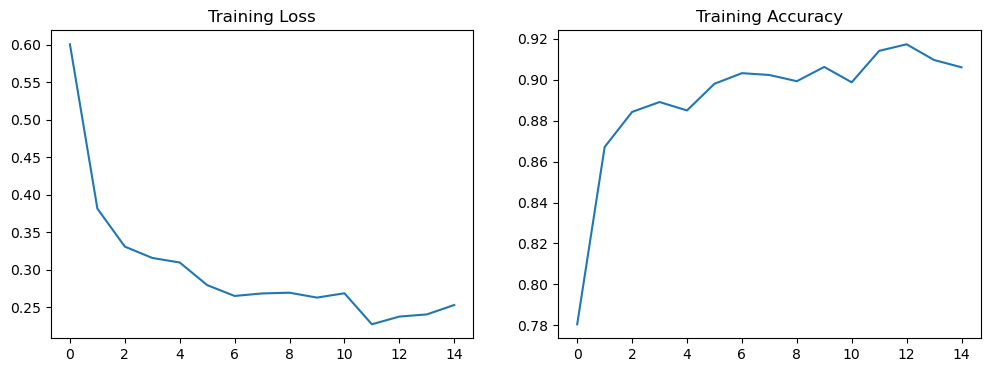

In [15]:
# 5. VISUALIZING RESULTS
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Loss')
plt.title('Training Loss')
plt.subplot(1, 2, 2)
plt.plot(history['acc'], label='Accuracy')
plt.title('Training Accuracy')
plt.show()

In [23]:
def generate_gradcam(model, img_tensor, target_layer):
    model.eval()
    
    # IMPORTANT: We must ensure the gradients are being tracked
    # even if we didn't train these layers.
    for param in model.parameters():
        param.requires_grad = True

    features = []
    gradients = []

    # Modern PyTorch hook (handles errors better)
    def save_feature(module, input, output):
        features.append(output.detach())
    
    def save_gradient(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())

    # Registering hooks on the target layer
    handle_f = target_layer.register_forward_hook(save_feature)
    handle_g = target_layer.register_full_backward_hook(save_gradient)

    # Forward pass
    output = model(img_tensor)
    _, target_class = torch.max(output, 1)
    
    # Backward pass
    model.zero_grad()
    output[0, target_class].backward()

    # Check if we successfully captured gradients
    if len(gradients) == 0:
        handle_f.remove()
        handle_g.remove()
        raise ValueError("Gradients not captured. Ensure target_layer is correct.")

    # Calculate Grad-CAM
    grad = gradients[0].cpu().numpy()[0]
    feat = features[0].cpu().numpy()[0]
    
    # Weighting the features by the average gradient
    weights = np.mean(grad, axis=(1, 2))
    cam = np.zeros(feat.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * feat[i, :, :]

    cam = np.maximum(cam, 0) # ReLU
    cam = cv2.resize(cam, (224, 224))
    
    # Normalize
    if cam.max() != 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min())

    # Clean up hooks
    handle_f.remove()
    handle_g.remove()
    
    return cam, target_class.item()

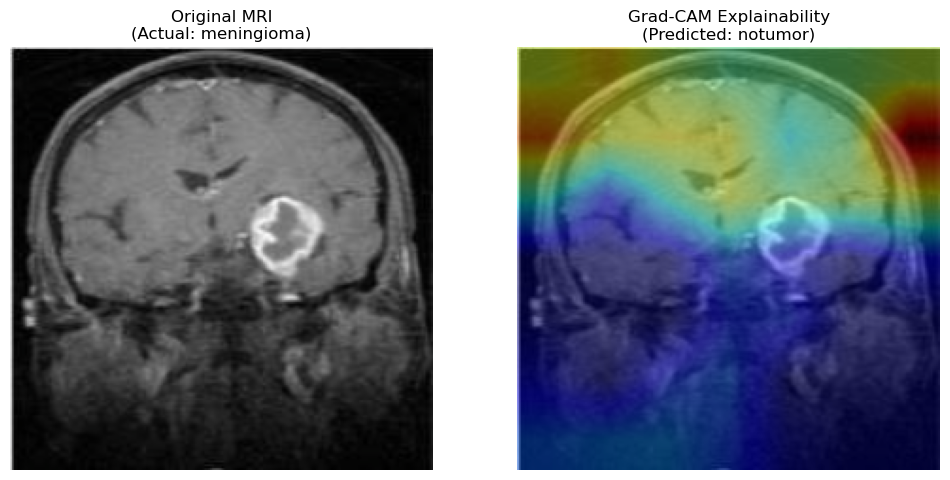

In [24]:
# 1. Get a sample
images, labels = next(iter(dataloaders['Testing']))
img_tensor = images[0].unsqueeze(0).to(device)
true_label = labels[0].item()

# 2. Target the last convolutional layer
# For ResNet50, model.layer4[-1] is the standard choice
target_layer = model.layer4[-1]

try:
    heatmap, pred_idx = generate_gradcam(model, img_tensor, target_layer)

    # 3. Process image for display
    img_np = images[0].permute(1, 2, 0).cpu().numpy()
    # Un-normalize
    img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_np = np.clip(img_np, 0, 1)

    # 4. Display
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(f"Original MRI\n(Actual: {class_names[true_label]})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_np)
    plt.imshow(heatmap, cmap='jet', alpha=0.4) # Overlay with transparency
    plt.title(f"Grad-CAM Explainability\n(Predicted: {class_names[pred_idx]})")
    plt.axis('off')

    plt.show()
    
except Exception as e:
    print(f"Error: {e}")